In [93]:
# K-Means에서 “몇 개로 나누는 게 제일 좋은가?” 를 정하는 핵심
# 최적의 k 값 찾기: 엘보우(elbow) 방법
# 클러스터의 응집도 측정하는 성능지표 / 각 데이터 포인터가 자신이 속한 클러스터의 중심과 얼마나 가까운지를 나타내는 총 거리합
# 클러스터가 많을수록 줄어드는 특징
# 그래프에서 k가 증가하면서 ineritia_ 감소폭이 급격히 줄어드는 지점이 적절한 k (이게 낮다고해서 무조건 좋은건 아님. 클러스터 많아지면 과적합될수도?)
# 거리기반 이므로 이상치에 민감.
# 스케일링 필수 
#km.inertia_ #그룹 안에서 데이터들이 중심과 얼마나 모여있는지(응집) 나타내는 숫자


# 만약 3개 그룹으로 나눴는데,
# 각 그룹의 중심에서 데이터들이 멀리 퍼져 있다면 → inertia 값이 크다
# 각 그룹 안의 데이터들이 중심 근처에 딱딱 모여 있다면 → inertia 값이 작다
# 👉 그래서 inertia는 작을수록 좋은 모델처럼 보이죠.


# 그룹 수(k)를 늘리면…
# 데이터가 더 잘게 쪼개져서 각 그룹 안 데이터들이 더 가까워지니까 → inertia 값이 계속 줄어요.
# 하지만 너무 많이 나누면 의미 없는 과적합(overfitting) 이 돼요 😵‍💫
# (예: 사람 10명을 “10개의 그룹”으로 나누면 당연히 완벽히 가까움 → 하지만 쓸모 없음)

# 💪 그래서 나온 게 엘보우 방법 
# 여러 개의 k 값을 시도해 보고,
# 각각의 inertia_를 구해서 그래프로 그리면 이런 모양이 나와요 👇
# 📍 그래프가 급격히 꺾이는 부분 (팔꿈치 모양처럼 보이는 곳)이 “적절한 k” 값이에요.
# 그래서 엘보우(elbow) 라고 불러요 💪

🧭 K-Means 모델 사용 순서 정리

1. 데이터 가져오기
2. 결측치 확인 (info() => 문자처리 pd.to_numeric (error='coerce') => NaN 확인 df.isna().sum() / missingno)
3. 결측치 처리 (dropna 또는 fillna)
4. 이상치(outlier) 확인 (boxplot)
5. 스케일링 (from sklearn.preprocessing import StandardScaler /n scaler = StandardScaler())
6. 엘보우 방법으로 최적 k 찾기 (inertias)
7. 최적의 k로 모델 학습 (km = KMeans(n_clusters=3, random_state=42) /n km.fit(X_scaled))
8. 결과 확인 km.labels_
9. 필요하면 시각화

| 단계           | 설명              | 필수여부    |
| ------------ | --------------- | ------- |
| 1. 데이터 불러오기  | CSV나 데이터셋 읽기 (pd.read)   | ✅       |
| 2. 결측치 확인    | object(info / pd.to_numeric (error='coerce')) 및 NaN 탐색 (df.isna().sum() / missingno)        | ✅       |
| 3. 결측치 처리    | NaN 제거/대체 (drop / dropna / fillna)      | ✅       |
| 4. 이상치(outlier) 확인    | 너무 큰 값, 작은 값 탐색 (boxplot) | ⚙️ (권장) |
| 5. 스케일링      | 거리 기반이므로 꼭 필요 <br> (from sklearn.preprocessing import StandardScaler /n scaler = StandardScaler())   | ✅       |
| 6. 엘보우로 k 결정 | 적절한 클러스터 개수 찾기 (inertias)  | ✅       |
| 7. 모델 학습     | km = KMeans(n_clusters=3, random_state=42) /n km.fit(X_scaled) | ✅       |
| 8. 그룹 결과 붙이기 | km.labels_ | ✅       |
| 9. 시각화       | 그룹 시각 확인        | ⚙️ (선택) |


'''
GPT

🧭 K-Means 모델 사용 순서 정리

✅ 1️⃣ 데이터 가져오기
df = pd.read_csv('data.csv')


👉 분석하고 싶은 데이터를 불러와요.
(예: 학생 점수표, 고객 구매정보, 꽃의 길이와 너비 등)

✅ 2️⃣ 결측치(NaN) 확인
df.isna().sum()


👉 비어 있는 값이 있는지 확인해요.
(빈칸이 있으면 계산이 제대로 안 돼요)

✅ 3️⃣ 결측치 처리
df = df.dropna()   # 또는 평균값으로 채우기


👉 비어 있는 값을 지우거나, 평균 등으로 채워요.
K-Means는 수학 계산을 많이 하기 때문에 NaN이 있으면 오류나요 ⚠️

✅ 4️⃣ 이상치(Outlier) 확인 (선택사항이지만 중요!)
df.describe()
plt.boxplot(df['column'])


👉 너무 크거나 작은 값이 있으면 그룹이 이상하게 나뉘어요 😵‍💫
(예: 키 160~180인데 300이 하나 있으면 중심이 틀어져버림)

→ 필요하면 제거하거나 조정!

✅ 5️⃣ 스케일링 (⚡필수!)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


👉 K-Means는 거리(distance) 로 묶는 모델이에요.
즉, “얼마나 가까운지”를 기준으로 그룹을 만드는데,

만약 키(단위 cm)와 몸무게(단위 kg)가 같이 있다면
숫자 크기가 다르니까 공평하지 않아요 😥

그래서 모든 변수를 비슷한 범위(평균 0, 표준편차 1) 로 바꿔주는 거예요.

✅ 6️⃣ 엘보우 방법으로 최적의 k 찾기
inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1,10), inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()


👉 그래프를 그려서 팔꿈치(elbow) 처럼 꺾이는 지점을 찾으면
그게 가장 적절한 그룹 수(k) 에요 💪

✅ 7️⃣ 최적의 k로 모델 학습
km = KMeans(n_clusters=3, random_state=42)
km.fit(X_scaled)

✅ 8️⃣ 결과 확인
df['cluster'] = km.labels_


👉 각 데이터가 어떤 그룹(cluster)에 속했는지 확인할 수 있어요.
예를 들어:

학생	키	몸무게	cluster
철수	170	65	0
영희	158	50	1
민수	182	80	2
✅ 9️⃣ 시각화 (선택사항)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=km.labels_)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], c='red', marker='X')
plt.show()


👉 각 그룹이 어디에 모였는지 눈으로 확인할 수 있어요 👀


'''

In [145]:
############ CC-GENERAL.csv 데이터 설명 #################

- CUST_ID	신용카드 사용자 식별자 (범주형 데이터)
- BALANCE	사용자가 구매를 위해 계좌에 남겨놓은 잔액
- BALANCE_FREQUENCY	잔액이 얼마나 자주 업데이트되는지를 나타내는 점수 (0 ~ 1 사이, 1에 가까울수록 자주 업데이트됨)
- PURCHASES	계좌를 통해 이루어진 총 구매 금액
- ONEOFF_PURCHASES	한 번에 이루어진 최대 금액의 구매
- INSTALLMENTS_PURCHASES	할부로 이루어진 구매 금액 총합
- CASH_ADVANCE	사용자가 받은 선불 현금 금액
- PURCHASES_FREQUENCY	얼마나 자주 구매가 이루어졌는지를 나타내는 점수 (0 ~ 1 사이)
- ONEOFFPURCHASESFREQUENCY	한 번에 이루어지는 구매의 빈도 (0 ~ 1 사이)
- PURCHASESINSTALLMENTSFREQUENCY	할부 구매가 얼마나 자주 이루어졌는지를 나타내는 빈도 점수 (0 ~ 1 사이)
- CASHADVANCEFREQUENCY	선불 현금 인출이 얼마나 자주 이루어졌는지 (0 ~ 1 사이)
- CASHADVANCETRX	선불 현금 인출 거래 횟수
- PURCHASES_TRX	총 구매 거래 횟수
- CREDIT_LIMIT	사용자에게 부여된 신용카드 한도
- PAYMENTS	사용자가 지불한 총 금액
- MINIMUM_PAYMENTS	사용자가 납부한 최소 금액
- PRCFULLPAYMENT	전액 결제한 비율 (0 ~ 1 사이)
- TENURE	사용자의 신용카드 사용 기간

In [94]:
import pandas as pd
df=pd.read_csv('D:/0python_SNC/15pandas/pandas-data-analysis-main/part7/data/CC-GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [95]:
df.info()  
#결측치 데이터 확인: 
#CREDIT_LIMIT  8949 ==> 1개 없으니 삭제해도 될듯
#MINIMUM_PAYMENTS 8637 ==> 확인하기. missingno 
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


<Axes: >

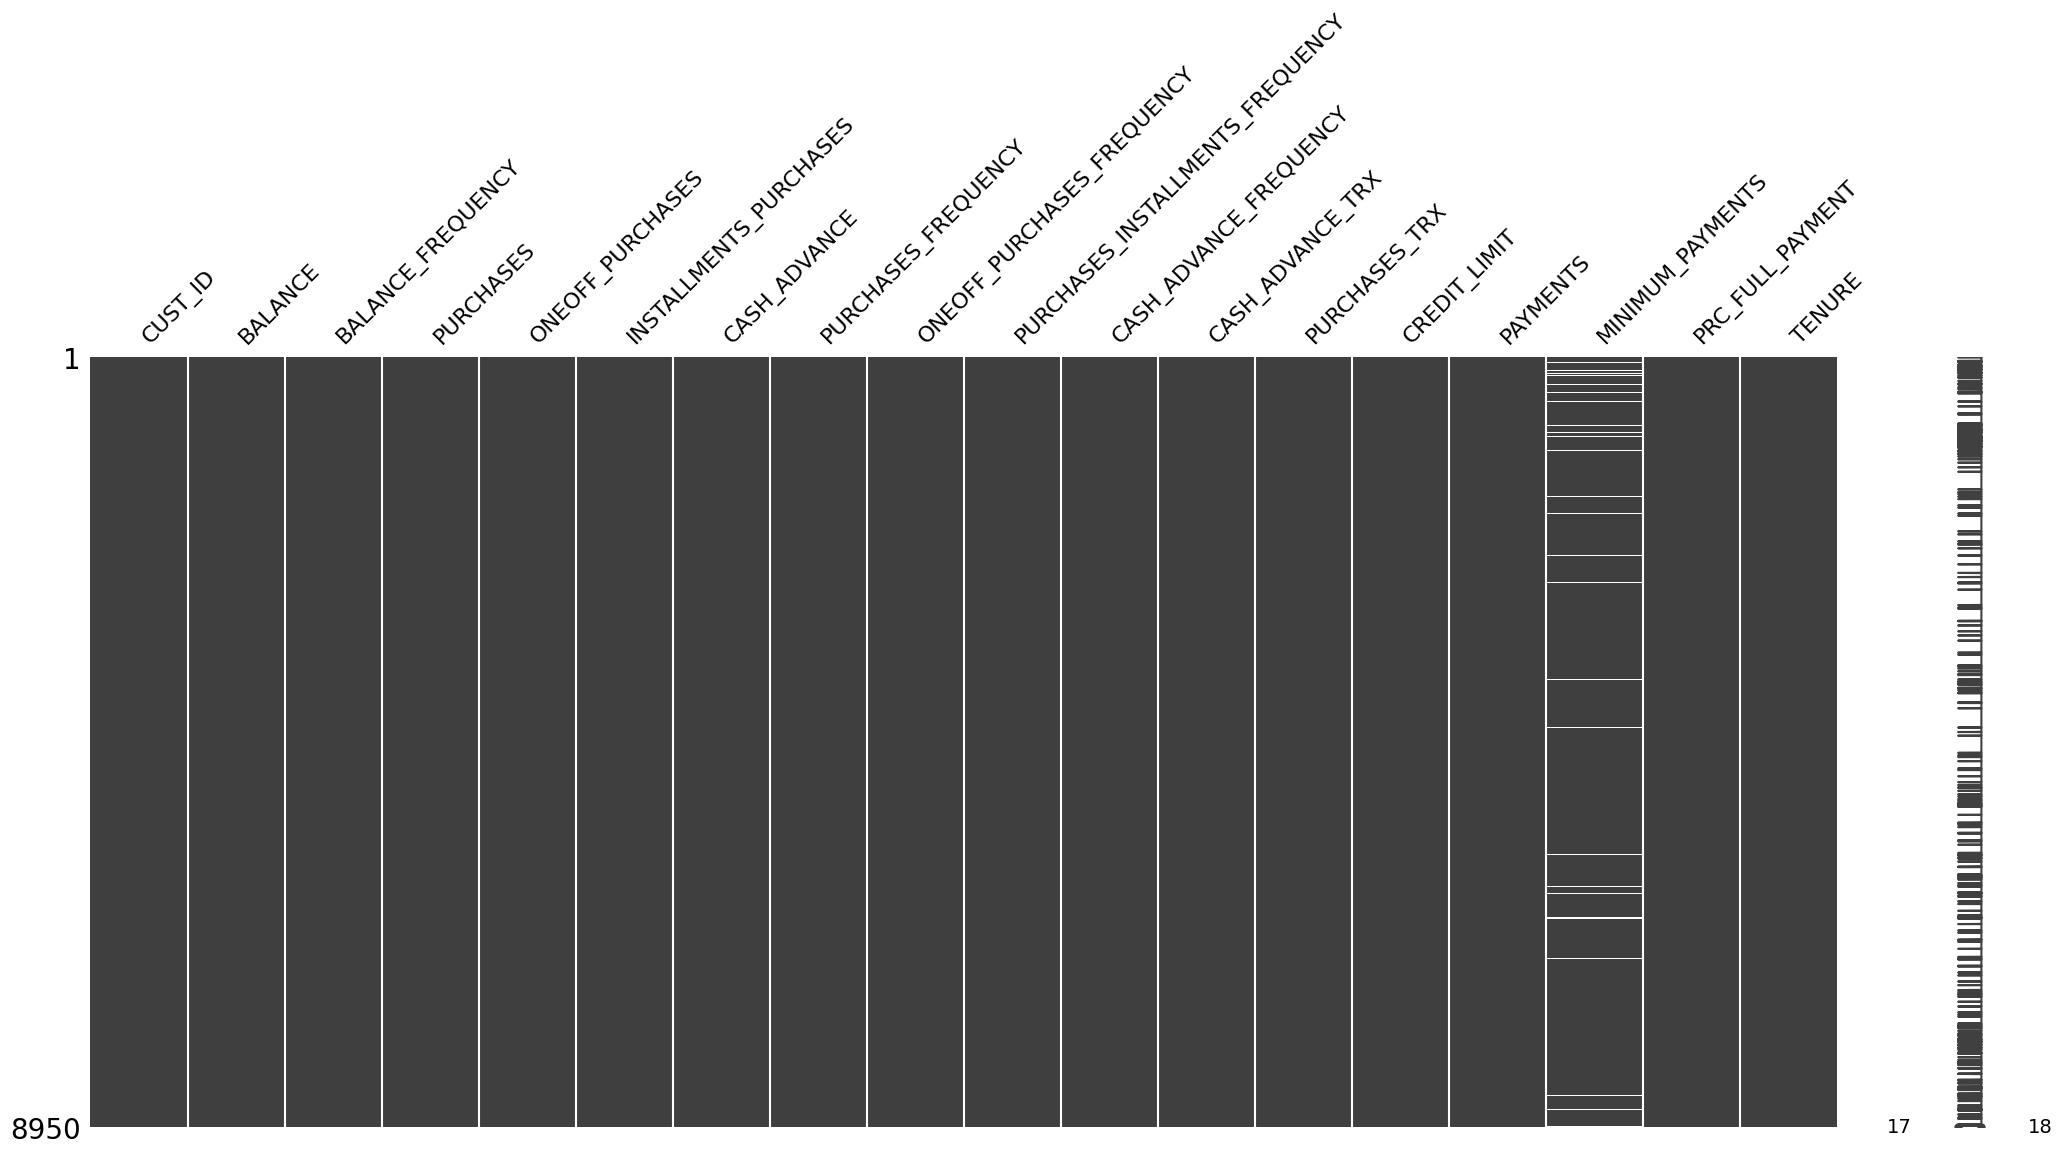

In [96]:
import missingno as msno
msno.matrix(df)
#MINIMUM_PAYMENTS 8637 ==> 결측치가 몰려있으니, 이건 삭제하지말고 채워주는 것으로 진행

In [97]:
#데이터 및 결측치 처리
credit_df=df.copy()
credit_df=credit_df.drop(columns=['CUST_ID'])  #CUST_ID 불필요해서 삭제
credit_df=credit_df.dropna(subset=['CREDIT_LIMIT'])  #CREDIT_LIMIT 1개 결측치 행 삭제
credit_df.CREDIT_LIMIT.isna().sum()
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8949 non-null   float64
 1   BALANCE_FREQUENCY                 8949 non-null   float64
 2   PURCHASES                         8949 non-null   float64
 3   ONEOFF_PURCHASES                  8949 non-null   float64
 4   INSTALLMENTS_PURCHASES            8949 non-null   float64
 5   CASH_ADVANCE                      8949 non-null   float64
 6   PURCHASES_FREQUENCY               8949 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8949 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8949 non-null   float64
 10  CASH_ADVANCE_TRX                  8949 non-null   int64  
 11  PURCHASES_TRX                     8949 non-null   int64  
 12  CREDIT_LIMI

In [98]:
#MINIMUM_PAYMENTS 결측치는 mean 으로 채우기 
credit_df.MINIMUM_PAYMENTS=credit_df.MINIMUM_PAYMENTS.fillna(credit_df.MINIMUM_PAYMENTS.mean())


'''
#sklean을 이용해서 결측치를 채우는 방법
#각 컬럼의 결측치를 모두 평균으로 채움. 하나의 컬럼이 아닌 전체데이터에서.
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') 
imputer.fit_transform(credit_df) 
'''

"\n#sklean을 이용해서 결측치를 채우는 방법\n#각 컬럼의 결측치를 모두 평균으로 채움. 하나의 컬럼이 아닌 전체데이터에서.\nfrom sklearn.impute import SimpleImputer\nimputer = SimpleImputer(strategy='mean') \nimputer.fit_transform(credit_df) \n"

In [99]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8949 non-null   float64
 1   BALANCE_FREQUENCY                 8949 non-null   float64
 2   PURCHASES                         8949 non-null   float64
 3   ONEOFF_PURCHASES                  8949 non-null   float64
 4   INSTALLMENTS_PURCHASES            8949 non-null   float64
 5   CASH_ADVANCE                      8949 non-null   float64
 6   PURCHASES_FREQUENCY               8949 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8949 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8949 non-null   float64
 10  CASH_ADVANCE_TRX                  8949 non-null   int64  
 11  PURCHASES_TRX                     8949 non-null   int64  
 12  CREDIT_LIMI

<Axes: >

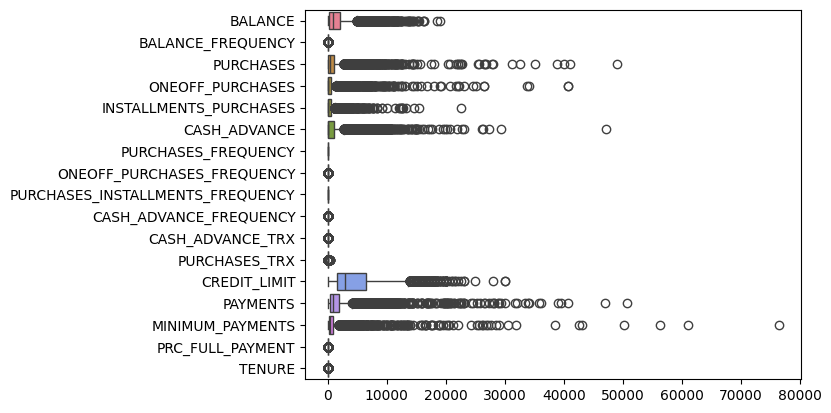

In [100]:
# 이상치여부 확인하기 - boxplot
import seaborn as sns
sns.boxplot(credit_df, orient='h')

# 👉 너무 크거나 작은 값이 있으면 그룹이 이상하게 나뉘어요 😵‍💫
# (예: 키 160~180인데 300이 하나 있으면 중심이 틀어져버림)
# → 필요하면 제거하거나 조정!

In [101]:
#정규화(스케일링)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled =scaler.fit_transform(credit_df)  #X,y 나눠서 하지 않고 전체 데이터를 한꺼번에 정규화 해도 됨 ==> 하고나면 numpy로 바뀜
# df_scaled.head() => 오류. numpy 되므로.

100%|██████████| 14/14 [00:00<00:00, 57.75it/s]


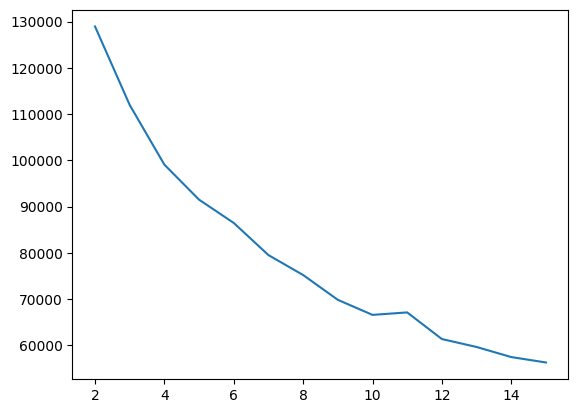

In [107]:
# 최적의 k 찾기: 엘보우 방법
from sklearn.cluster import KMeans
from tqdm import tqdm  #진행사항 확인
k_lists = []
for k in tqdm(range(2,16)):
    knn = KMeans(n_clusters=k)
    knn.fit(df_scaled)
    k_lists.append(knn.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(2,16), k_lists)

# 그래프를 확인해서 k=4로 설정.

In [ ]:
# 그래프를 확인해서 k=4 (n_clusters=4) 로 설정.
kmn = KMeans(n_clusters=4,random_state=42)
clusters =kmn.fit_predict(df_scaled)
credit_df['clusters']=clusters

In [110]:
credit_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,clusters
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.304943,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


In [111]:
# 클러스터를 구분하는데 중요도가 높은 컬럼 두개 찾기
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(credit_df.drop(columns=['clusters']), credit_df.clusters)  #x로 cluster 제외한 모든 컬럼 #y(정답)로 cluster
tree.feature_importances_

array([0.00902932, 0.        , 0.3087426 , 0.        , 0.        ,
       0.30372584, 0.        , 0.        , 0.        , 0.02474178,
       0.        , 0.03875148, 0.        , 0.        , 0.        ,
       0.        , 0.31500898])

In [143]:
import numpy as np
top2 = np.argsort(tree.feature_importances_)[::-1][:2]  
#[::-1] ==> [start:stop:step]step=-1 → 거꾸로 뒤집기
#[:2] ==> [start:stop] → start~stop-1 의미: 가장 큰 값 2개의 인덱스만 뽑았다
top2

array([16,  2])

In [124]:
# array([16,  2]) column .. 
# credit_df.columns[[16,2]]  
credit_df.columns[top2]  

Index(['TENURE', 'PURCHASES'], dtype='object')

<Axes: xlabel='TENURE', ylabel='PURCHASES'>

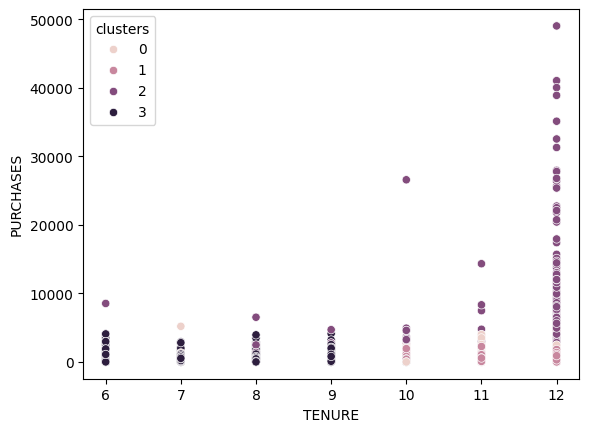

In [125]:
sns.scatterplot(data=credit_df, x='TENURE', y='PURCHASES', hue='clusters')

In [126]:
# 클러스터를 구분하는데 중요도가 높은 컬럼 4개 찾기
import numpy as np
top4 = np.argsort(tree.feature_importances_)[::-1][:4]
top4

array([16,  2,  5, 11])

In [127]:

credit_df.columns[top4]  

Index(['TENURE', 'PURCHASES', 'CASH_ADVANCE', 'PURCHASES_TRX'], dtype='object')

In [128]:
temp = credit_df.loc[:, credit_df.columns[top4]  ]
temp['clusters'] = clusters
temp

,TENURE,PURCHASES,CASH_ADVANCE,PURCHASES_TRX,clusters
0,12,95.40,0.000000,2,1
1,12,0.00,6442.945483,0,0
2,12,773.17,0.000000,12,1
3,12,1499.00,205.788017,1,1
4,12,16.00,0.000000,1,1
...,...,...,...,...,...
8945,6,291.12,0.000000,6,3
8946,6,300.00,0.000000,6,3
8947,6,144.40,0.000000,5,3
8948,6,0.00,36.558778,0,3


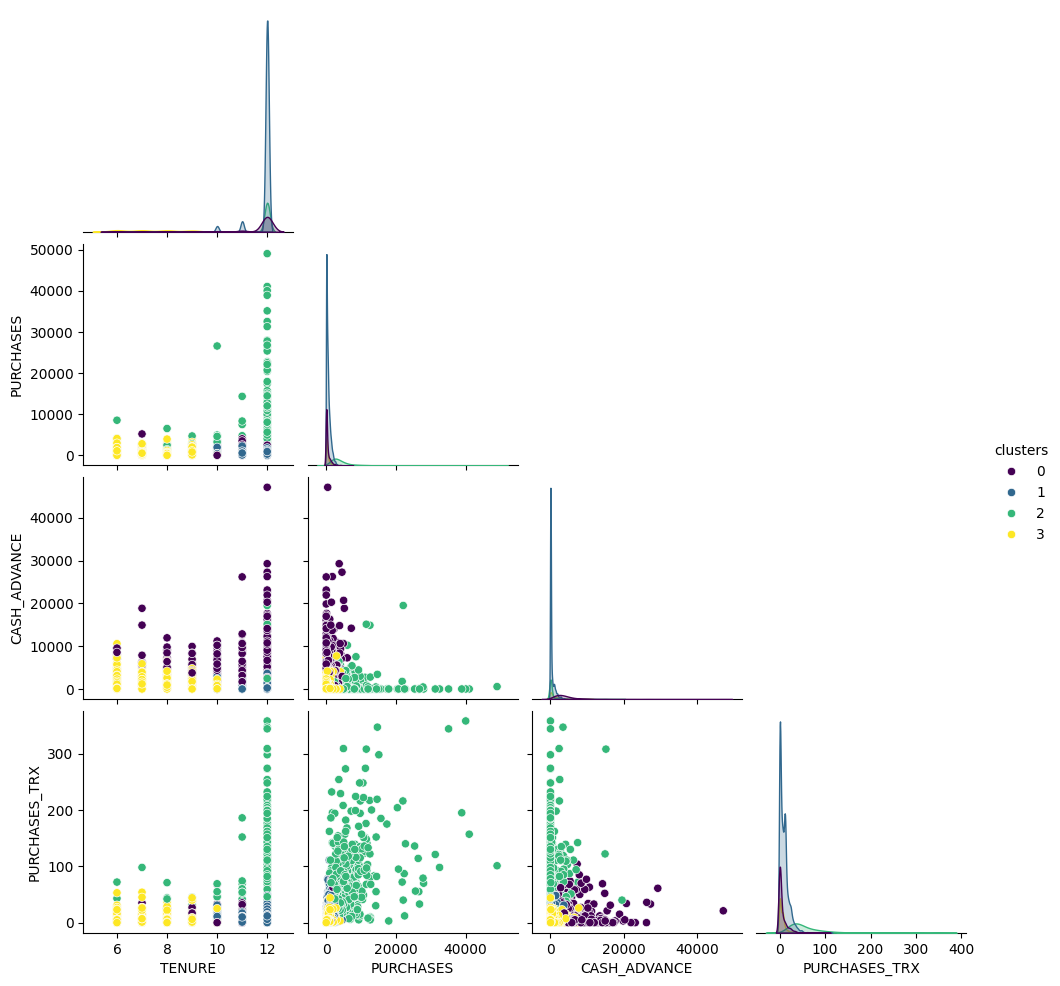

In [130]:
sns.pairplot(temp, hue='clusters', palette='viridis', corner=True)
plt.show()

C:\Users\playdata2\AppData\Local\Temp\ipykernel_10480\2861737591.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x='clusters', y=colname, ax=ax[i], palette='viridis')
C:\Users\playdata2\AppData\Local\Temp\ipykernel_10480\2861737591.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x='clusters', y=colname, ax=ax[i], palette='viridis')
C:\Users\playdata2\AppData\Local\Temp\ipykernel_10480\2861737591.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x='clusters', y=colname, ax=ax[i], palette='viridis')
C

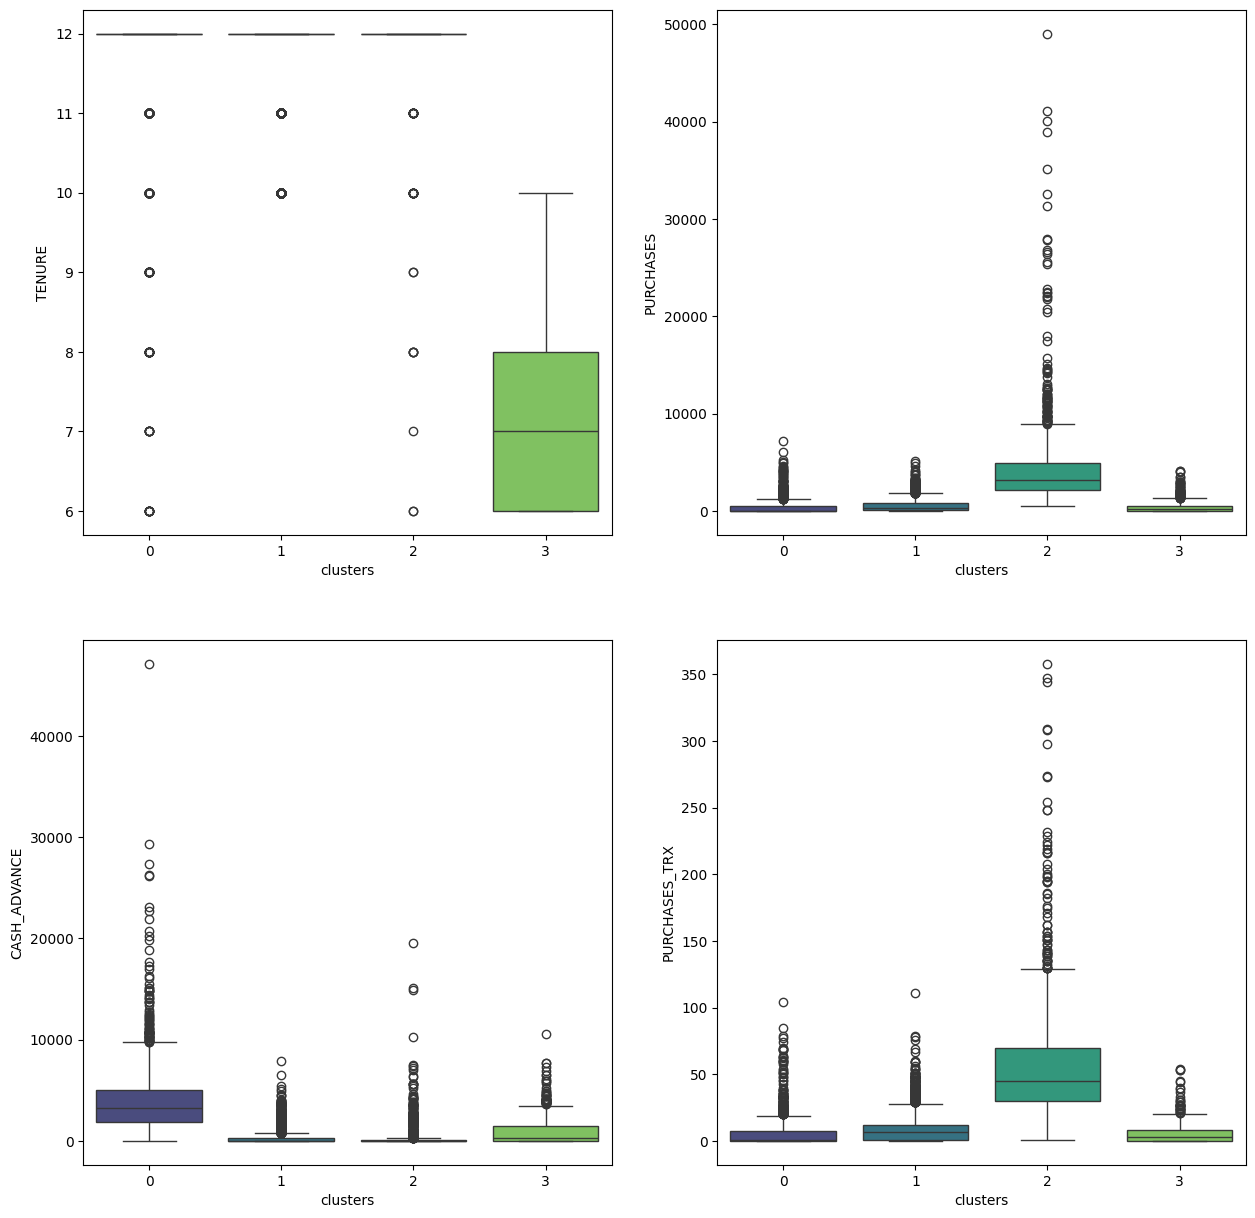

In [142]:
# boxplot
credit_df.columns[top4]  
fig,ax = plt.subplots(2,2, figsize=(15,15))
ax = ax.flatten()
for i, colname in enumerate(temp.columns):
    if i !=4:
        sns.boxplot(data=temp, x='clusters', y=colname, ax=ax[i], palette='viridis')


In [ ]:
# 상기 그래프 해석

# TENURE	사용자의 신용카드 사용 기간
# 클러스터 0 1 2 박스가 맨위에 붙었다. ==> 이 그룹의 고객들은 대부분 만기회원 ==> 충성고객
# 클러스터 3 은 6~8 사이이기 때문에 상대적으로 볼때 신규 또는 중간 가입기간

# PURCHASES	계좌를 통해 이루어진 총 구매 금액
# 클러스트2 구매금액이 높다 ==> VVIP 일 확률이 높다
# 나머지 클래스들은 총 구매액이 낮다

# CASH_ADVANCE	사용자가 받은 선불 현금 금액
# 클래스터0이 현금 서비스를 주로 사용하는 집단

# PURCHASES_TRX	총 구매 거래 횟수
# 클러스트2 거래횟수가 많다 => 자주 쓴다

# 총 결론
# ==> 클러스트2가 충성고객이면서, 거래횟수도 많고, 구매금액도 많기 때문에 여기에 마케팅을 강화하자?!
# ==> 클러스트0은 현금서비스를 많이하는데, 구매액이 낮으므로... 연체될 가능성이 있는 집단.
#